#**Telecom X - Análisis de Evasión de Clientes**

#**Diccionario de datos**
customerID: número de identificación único de cada cliente

Churn: si el cliente dejó o no la empresa

gender: género (masculino y femenino)

SeniorCitizen: información sobre si un cliente tiene o no una edad
igual o mayor a 65 años

Partner: si el cliente tiene o no una pareja

Dependents: si el cliente tiene o no dependientes

tenure: meses de contrato del cliente

PhoneService: suscripción al servicio telefónico

MultipleLines: suscripción a más de una línea telefónica

InternetService: suscripción a un proveedor de internet

OnlineSecurity: suscripción adicional de seguridad en línea

OnlineBackup: suscripción adicional de respaldo en línea

DeviceProtection: suscripción adicional de protección del dispositivo

TechSupport: suscripción adicional de soporte técnico, menor tiempo de espera

StreamingTV: suscripción de televisión por cable

StreamingMovies: suscripción de streaming de películas
Contract: tipo de contrato

PaperlessBilling: si el cliente prefiere recibir la factura en línea

PaymentMethod: forma de pago

Charges.Monthly: total de todos los servicios del cliente por mes

Charges.Total: total gastado por el cliente

#📌 Extracción

###**Importar los datos y convertirlos en un DataFrame**

In [ ]:
import pandas as pd

In [ ]:
url = ('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')

In [ ]:
Telecom_X = pd.read_json(url)

In [ ]:
Telecom_X.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#**🔧 Transformación**

##**Conocer el conjunto de datos.**

####**Explorar las columnas del dataset y verificar sus tipos de datos.**

In [ ]:
Telecom_X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
Telecom_X.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


####**Observar qué variables hay dentro del diccionariocustomer, phone, internet y account.**

In [ ]:
Telecom_X["customer"].iloc[0]




{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'Yes',
 'tenure': 9}

In [ ]:
Telecom_X["phone"].iloc[0]



{'PhoneService': 'Yes', 'MultipleLines': 'No'}

In [ ]:
Telecom_X["internet"].iloc[0]

{'InternetService': 'DSL',
 'OnlineSecurity': 'No',
 'OnlineBackup': 'Yes',
 'DeviceProtection': 'No',
 'TechSupport': 'Yes',
 'StreamingTV': 'Yes',
 'StreamingMovies': 'No'}

In [ ]:
Telecom_X["account"].iloc[0]

{'Contract': 'One year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Mailed check',
 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}

####**Convertir los diccionarios en columnas normales.**

In [ ]:
Telecom_X_customer = pd.json_normalize(Telecom_X["customer"])
Telecom_X_phone = pd.json_normalize(Telecom_X["phone"])
Telecom_X_internet = pd.json_normalize(Telecom_X["internet"])
Telecom_X_account = pd.json_normalize(Telecom_X["account"])

In [ ]:
# Unir todo al DataFrame original
Telecom_X_normalizado = pd.concat(
    [Telecom_X.drop(columns=["customer", "phone", "internet", "account"]),
     Telecom_X_customer,
     Telecom_X_phone,
     Telecom_X_internet,
     Telecom_X_account],
    axis=1
)

####**Explorar de nuevo el conjunto de datos y verificar sus tipos de datos.**

In [ ]:
Telecom_X_normalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
Telecom_X_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
Telecom_X_normalizado.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


##**Comprobación de incoherencias en los datos.**

####**Verificar valores ausentes.**

In [ ]:
Telecom_X_normalizado.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


####**Verificar espacios en columnas de tipo objecto, entero y float**

In [ ]:
for col in Telecom_X_normalizado.select_dtypes(include="object").columns:
    cantidad = (Telecom_X_normalizado[col].str.strip() == "").sum()
    print(f"{col}: {cantidad}")

customerID: 0
Churn: 224
gender: 0
Partner: 0
Dependents: 0
PhoneService: 0
MultipleLines: 0
InternetService: 0
OnlineSecurity: 0
OnlineBackup: 0
DeviceProtection: 0
TechSupport: 0
StreamingTV: 0
StreamingMovies: 0
Contract: 0
PaperlessBilling: 0
PaymentMethod: 0
Charges.Total: 11


In [ ]:
for col in Telecom_X_normalizado.select_dtypes(include=["int", "float"]).columns:
    cantidad = Telecom_X_normalizado[col].isnull().sum()
    print(f"{col}: {cantidad}")

SeniorCitizen: 0
tenure: 0
Charges.Monthly: 0


####**Verificar duplicados.**

In [ ]:
Telecom_X_normalizado.duplicated().sum()

np.int64(0)

####**Verificar errores de formato.**

In [ ]:
Telecom_X_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Telecom X: Análisis de Evasión de Clientes (Churn)
Este repositorio contiene el análisis exploratorio y tratamiento de datos para identificar los factores que impulsan la pérdida de clientes en una empresa de telecomunicaciones.


Objetivo del Proyecto
El objetivo principal es transformar datos históricos de clientes en insights estratégicos que permitan a Telecom X reducir su tasa de abandono (Churn). El enfoque se centra en entender la relación entre la lealtad temporal, los costos de servicio y las características demográficas.

Herramientas y Librerías Utilizadas
Para este desafío se utilizó el ecosistema de ciencia de datos de Python:

Pandas: Para la limpieza, normalización y segmentación de datos.

Matplotlib & Seaborn: Para la creación de visualizaciones estadísticas avanzadas (Histogramas apilados, Boxplots).

Jupyter Notebooks: Como entorno de desarrollo y documentación del análisis.

Hallazgos Principales (Insights)
A través del Análisis Exploratorio de Datos (EDA), se identificaron patrones críticos:

Zona de Riesgo Temporal: La mayoría de las cancelaciones ocurren durante los primeros 12 meses de contrato.

Sensibilidad al Gasto: Los clientes con cargos mensuales elevados y contratos de mes a mes presentan la mayor probabilidad de fuga.

Anclas de Retención: El uso de servicios adicionales como soporte técnico y seguridad en línea está correlacionado con una mayor permanencia.

Estructura del Dataset
El análisis se basó en un diccionario de datos que incluye:

Variables Demográficas: Género, SeniorCitizen, Partner, Dependents.

Servicios: PhoneService, MultipleLines, InternetService, OnlineSecurity, etc.

Financieras: MonthlyCharges, TotalCharges.

Target: Churn (Yes/No).



####**Verificar inconsistencias en categorías**

In [ ]:
columnas_objeto = Telecom_X_normalizado.select_dtypes(include="object").columns

In [ ]:
for col in columnas_objeto:
    print(f"\nColumna: {col}")
    print(Telecom_X_normalizado[col].unique())


Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Columna: Churn
['No' 'Yes' '']

Columna: gender
['Female' 'Male']

Columna: Partner
['Yes' 'No']

Columna: Dependents
['Yes' 'No']

Columna: PhoneService
['Yes' 'No']

Columna: MultipleLines
['No' 'Yes' 'No phone service']

Columna: InternetService
['DSL' 'Fiber optic' 'No']

Columna: OnlineSecurity
['No' 'Yes' 'No internet service']

Columna: OnlineBackup
['Yes' 'No' 'No internet service']

Columna: DeviceProtection
['No' 'Yes' 'No internet service']

Columna: TechSupport
['Yes' 'No' 'No internet service']

Columna: StreamingTV
['Yes' 'No' 'No internet service']

Columna: StreamingMovies
['No' 'Yes' 'No internet service']

Columna: Contract
['One year' 'Month-to-month' 'Two year']

Columna: PaperlessBilling
['Yes' 'No']

Columna: PaymentMethod
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

Columna: Charges.Total
['593.3' '542.4' '280.8

In [ ]:
columnas_enteros = Telecom_X_normalizado.select_dtypes(include="int64").columns

In [ ]:
for col in columnas_enteros:
    print(f"\nColumna: {col}")
    print(Telecom_X_normalizado[col].unique())


Columna: SeniorCitizen
[0 1]

Columna: tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]


In [ ]:
columnas_flotantes = Telecom_X_normalizado.select_dtypes(include="float64").columns

In [ ]:
for col in columnas_flotantes:
    print(f"\nColumna: {col}")
    print(Telecom_X_normalizado[col].unique())


Columna: Charges.Monthly
[65.6  59.9  73.9  ... 91.75 68.8  67.85]


##**Manejo de inconsistencias**

####**Corregir errores de formato e inconsistencias en las categorías.**

####**Reemplazar por 0 las cadenas vacias en Charges.Total y convertir en float**

In [ ]:
Telecom_X_normalizado["Charges.Total"] = Telecom_X_normalizado["Charges.Total"].replace(" ", "0")

In [ ]:
Telecom_X_normalizado["Charges.Total"] = Telecom_X_normalizado["Charges.Total"].astype(float)

In [ ]:
Telecom_X_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


####**Reemplazar por nan los espacios en Churn**

In [ ]:
Telecom_X_normalizado["Churn"] = Telecom_X_normalizado["Churn"].str.strip()
Telecom_X_normalizado["Churn"] = Telecom_X_normalizado["Churn"].replace("", pd.NA)

In [ ]:
for col in Telecom_X_normalizado.select_dtypes(include="object").columns:
    cantidad = (Telecom_X_normalizado[col].str.strip() == "").sum()
    print(f"{col}: {cantidad}")

customerID: 0
Churn: 0
gender: 0
Partner: 0
Dependents: 0
PhoneService: 0
MultipleLines: 0
InternetService: 0
OnlineSecurity: 0
OnlineBackup: 0
DeviceProtection: 0
TechSupport: 0
StreamingTV: 0
StreamingMovies: 0
Contract: 0
PaperlessBilling: 0
PaymentMethod: 0


In [ ]:
Telecom_X_normalizado.tail(15)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
7252,9972-EWRJS,No,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.90
7253,9972-NKTFD,No,Female,0,No,No,28,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),54.65,1517.50
7254,9972-VAFJJ,No,Female,1,Yes,No,53,Yes,No,Fiber optic,...,Yes,Yes,Yes,Yes,No,One year,Yes,Electronic check,94.00,4871.45
7255,9974-JFBHQ,No,Male,0,No,Yes,64,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.15,6171.20
7256,9975-GPKZU,No,Male,0,Yes,Yes,46,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.75,856.50
7257,9975-SKRNR,No,Male,0,No,No,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,18.90,18.90
7258,9978-HYCIN,No,Male,1,Yes,Yes,47,Yes,No,Fiber optic,...,Yes,No,No,Yes,No,One year,Yes,Bank transfer (automatic),84.95,4018.05
7259,9979-RGMZT,No,Female,0,No,No,7,Yes,No,Fiber optic,...,Yes,No,No,Yes,Yes,One year,Yes,Mailed check,94.05,633.45
7260,9985-MWVIX,Yes,Female,0,No,No,1,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15
7261,9986-BONCE,Yes,Female,0,No,No,4,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.95,85.50


##**Crear Columna cuentas diarias.**

In [ ]:
Telecom_X_normalizado["Cuentas_Diarias"] = Telecom_X_normalizado["Charges.Monthly"] / 30

In [ ]:
Telecom_X_normalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


##**Estandarización y transformación de datos.**

In [ ]:
# Partner, Dependents, PhoneService, PaperlessBilling

In [ ]:
columnas_binarias = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in columnas_binarias:
    Telecom_X_normalizado[col] = Telecom_X_normalizado[col].map({"Yes": 1, "No": 0})

In [ ]:
Telecom_X_normalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [ ]:
Telecom_X_normalizado.columns = Telecom_X_normalizado.columns.str.lower()

In [ ]:
Telecom_X_normalizado.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges.monthly,charges.total,cuentas_diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis

##**Análisis descriptivo de los datos.**

In [ ]:
Telecom_X_normalizado.describe()

,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,charges.monthly,charges.total,cuentas_diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2277.182035,2.157337
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1389.200000,2.343333
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [ ]:
Telecom_X_normalizado.describe() * 100

,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,charges.monthly,charges.total,cuentas_diarias
count,726700.000000,726700.000000,726700.000000,726700.000000,726700.000000,726700.000000,726700.000000,726700.000000,726700.000000
mean,16.265309,48.410623,30.012385,3234.649787,90.271088,59.322967,6472.009770,227718.203523,215.733659
std,36.907426,49.978171,45.834314,2457.177289,29.637144,49.126514,3012.957189,226864.858662,100.431906
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1825.000000,0.000000,60.833333
25%,0.000000,0.000000,0.000000,900.000000,100.000000,0.000000,3542.500000,39620.000000,118.083333
50%,0.000000,0.000000,0.000000,2900.000000,100.000000,100.000000,7030.000000,138920.000000,234.333333
75%,0.000000,100.000000,100.000000,5500.000000,100.000000,100.000000,8987.500000,377852.500000,299.583333
max,100.000000,100.000000,100.000000,7200.000000,100.000000,100.000000,11875.000000,868480.000000,395.833333


In [ ]:
Telecom_X_normalizado.var(numeric_only=True) *100

,0
seniorcitizen,1.362158e+01
partner,2.497818e+01
dependents,2.100784e+01
tenure,6.037720e+04
phoneservice,8.783603e+00
paperlessbilling,2.413414e+01
charges.monthly,9.077911e+04
charges.total,5.146766e+08
cuentas_diarias,1.008657e+02


##**Distribución de evasión.**

###**Distribución y Proporción de clientes churn.**

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
Telecom_X_normalizado["churn"].value_counts()

,count
churn,
No,5174
Yes,1869


In [ ]:
Telecom_X_normalizado["churn"].value_counts(normalize=True) * 100

,proportion
churn,
No,73.463013
Yes,26.536987


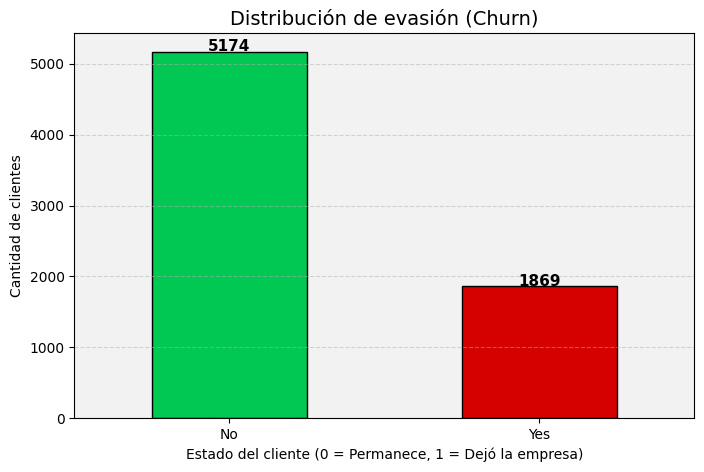

In [ ]:


conteo = Telecom_X_normalizado["churn"].value_counts().sort_index()

plt.figure(figsize=(8,5))
ax = conteo.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    edgecolor="black"
)

plt.title("Distribución de evasión (Churn)", fontsize=14)
plt.xlabel("Estado del cliente (0 = Permanece, 1 = Dejó la empresa)")
plt.ylabel("Cantidad de clientes")

plt.xticks(rotation=0)
plt.gca().set_facecolor("#f2f2f2")


for i, valor in enumerate(conteo.values):
    ax.text(i, valor + 5, str(valor), ha='center', fontsize=11, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

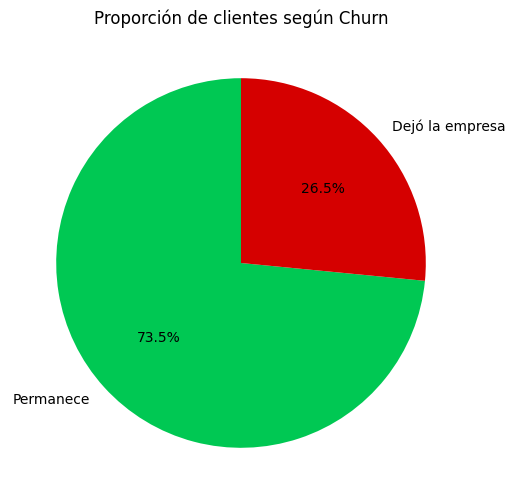

In [ ]:
conteo = Telecom_X_normalizado["churn"].value_counts().sort_index()

plt.figure(figsize=(6,6))

plt.pie(
    conteo,
    labels=["Permanece", "Dejó la empresa"],
    autopct="%1.1f%%",
    colors=["#00C853", "#D50000"],
    startangle=90
)

plt.title("Proporción de clientes según Churn")
plt.ylabel("")
plt.show()

##**Recuento de evasión por variables categóricas.**

###**Churn vs Genero**

In [ ]:
columna_genero = pd.crosstab(
    Telecom_X_normalizado["gender"],
    Telecom_X_normalizado["churn"],
)

columna_genero

churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


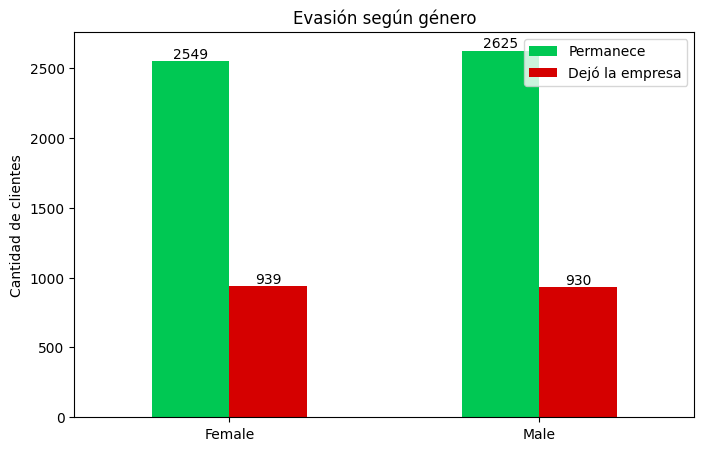

In [ ]:
ax = columna_genero.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    figsize=(8,5)
)

plt.title("Evasión según género")
plt.ylabel("Cantidad de clientes")
plt.xlabel("")
plt.legend(["Permanece", "Dejó la empresa"])
plt.xticks(rotation=0)


for container in ax.containers:
    ax.bar_label(container)

plt.show()

###**Churn vs Tipo de contrato**

In [ ]:
columna_contrato = pd.crosstab(
    Telecom_X_normalizado["contract"],
    Telecom_X_normalizado["churn"],
)

columna_contrato

churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


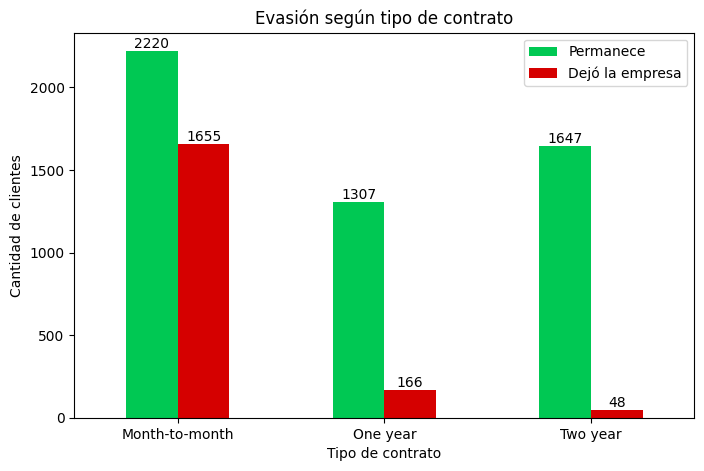

In [ ]:
ax = columna_contrato.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    figsize=(8,5)
)

plt.title("Evasión según tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.xlabel("Tipo de contrato")
plt.legend(["Permanece", "Dejó la empresa"])
plt.xticks(rotation=0)

# Agregar valores encima
for container in ax.containers:
    ax.bar_label(container)

plt.show()

###**Churn vs Método de pago**

In [ ]:
columna_pago = pd.crosstab(
    Telecom_X_normalizado["paymentmethod"],
    Telecom_X_normalizado["churn"],
   )

columna_pago

churn,No,Yes
paymentmethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


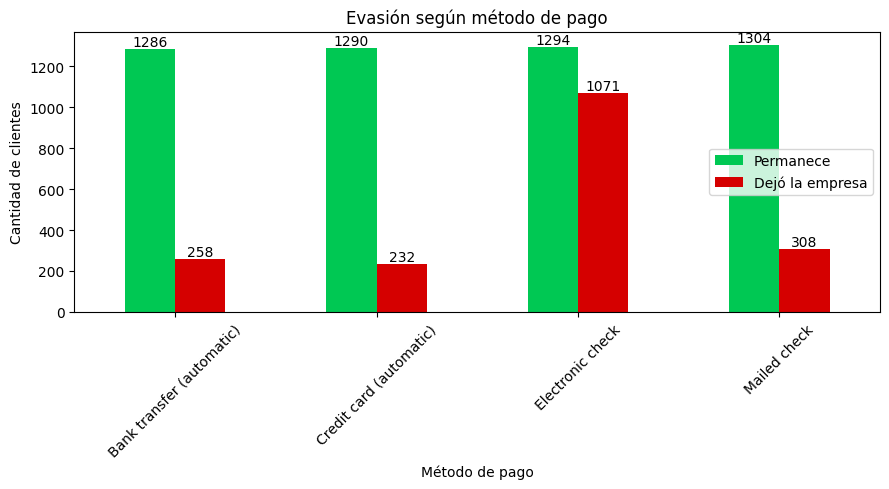

In [ ]:
ax = columna_pago.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    figsize=(9,5)
)

plt.title("Evasión según método de pago")
plt.ylabel("Cantidad de clientes")
plt.xlabel("Método de pago")
plt.legend(["Permanece", "Dejó la empresa"])
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

###**Churn según InternetService**

In [ ]:
columna_internet = pd.crosstab(
    Telecom_X_normalizado["internetservice"],
    Telecom_X_normalizado["churn"],
)

columna_internet


churn,No,Yes
internetservice,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


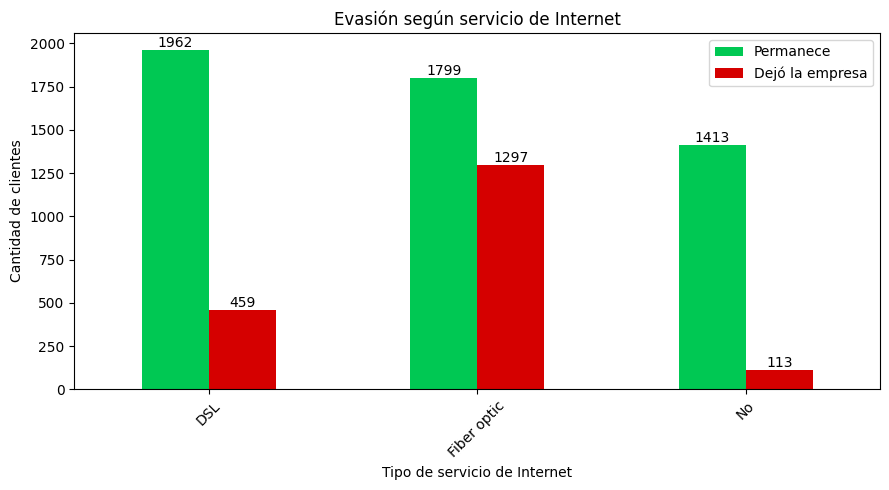

In [ ]:
ax = columna_internet.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    figsize=(9,5)
)


plt.title("Evasión según servicio de Internet")
plt.ylabel("Cantidad de clientes")
plt.xlabel("Tipo de servicio de Internet")
plt.legend(["Permanece", "Dejó la empresa"])
plt.xticks(rotation=45)



for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()



###**Churn según TechSupport**

In [ ]:
columna_tech = pd.crosstab(
    Telecom_X_normalizado["techsupport"],
    Telecom_X_normalizado["churn"],
)
columna_tech

churn,No,Yes
techsupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


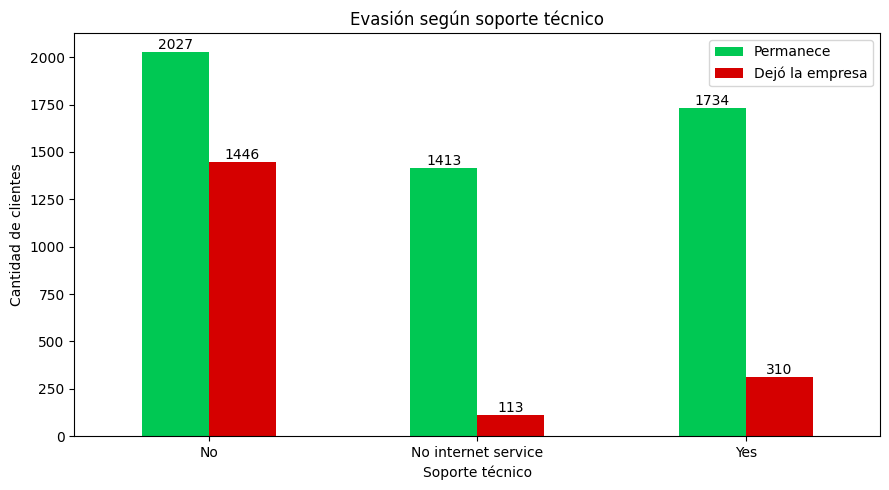

In [ ]:
ax = columna_tech.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    figsize=(9,5)
)

plt.title("Evasión según soporte técnico")
plt.ylabel("Cantidad de clientes")
plt.xlabel("Soporte técnico")
plt.legend(["Permanece", "Dejó la empresa"])
plt.xticks(rotation=0)


for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


###**Churn según OnlineSecurity**

In [ ]:
columna_security = pd.crosstab(
    Telecom_X_normalizado["onlinesecurity"],
    Telecom_X_normalizado["churn"],
)
columna_security

churn,No,Yes
onlinesecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


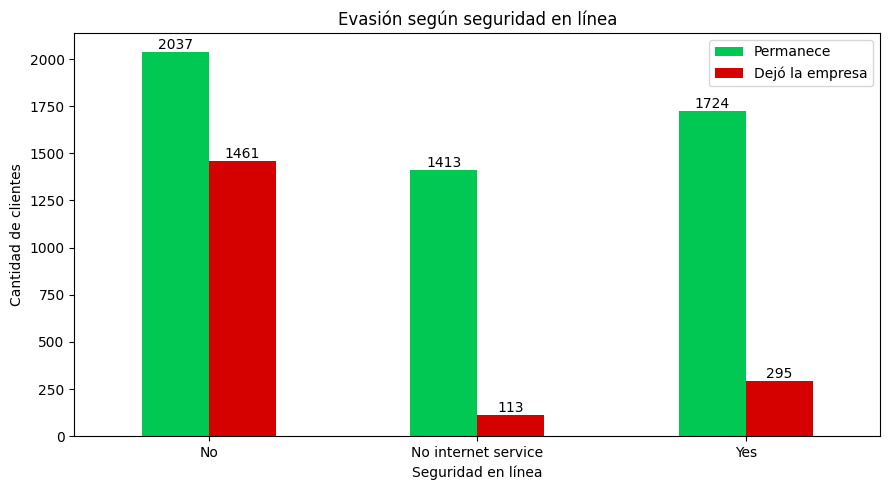

In [ ]:
ax = columna_security.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    figsize=(9,5)
)

plt.title("Evasión según seguridad en línea")
plt.ylabel("Cantidad de clientes")
plt.xlabel("Seguridad en línea")
plt.legend(["Permanece", "Dejó la empresa"])
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##**Conteo de evasión por variables numéricas.**

In [ ]:
#color=["#00C853", "#D50000"],

In [ ]:
columna_gasto = pd.crosstab(
    Telecom_X_normalizado["charges.total"],
    Telecom_X_normalizado["churn"],
)
columna_gasto

churn,No,Yes
charges.total,,
0.00,11,0
18.80,1,0
18.85,1,1
18.90,1,0
19.00,1,0
...,...,...
8564.75,1,0
8594.40,1,0
8670.10,1,0


In [ ]:
columna_gasto = pd.crosstab(
    Telecom_X_normalizado["tenure"],
    Telecom_X_normalizado["churn"],
)
columna_gasto

churn,No,Yes
tenure,,
0,11,0
1,233,380
2,115,123
3,106,94
4,93,83
...,...,...
68,91,9
69,87,8
70,108,11


In [297]:
# Conteo rápido de los 10 valores de antigüedad con más cancelaciones
print("Top 10 meses con más cancelaciones:")
print( Telecom_X_normalizado[ Telecom_X_normalizado['churn'] == 'Yes']['tenure'].value_counts().head(10))

# Estadísticas rápidas de gasto total para los que se fueron vs los que se quedaron
print("\nResumen de Gasto Total por Churn:")
print(Telecom_X_normalizado.groupby('churn')['charges.total'].describe())

Top 10 meses con más cancelaciones:
tenure
1     380
2     123
3      94
4      83
5      64
7      51
9      46
10     45
8      42
6      40
Name: count, dtype: int64

Resumen de Gasto Total por Churn:
        count         mean          std    min    25%       50%      75%  \
churn                                                                      
No     5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85   
Yes    1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30   

           max  
churn           
No     8672.45  
Yes    8684.80  


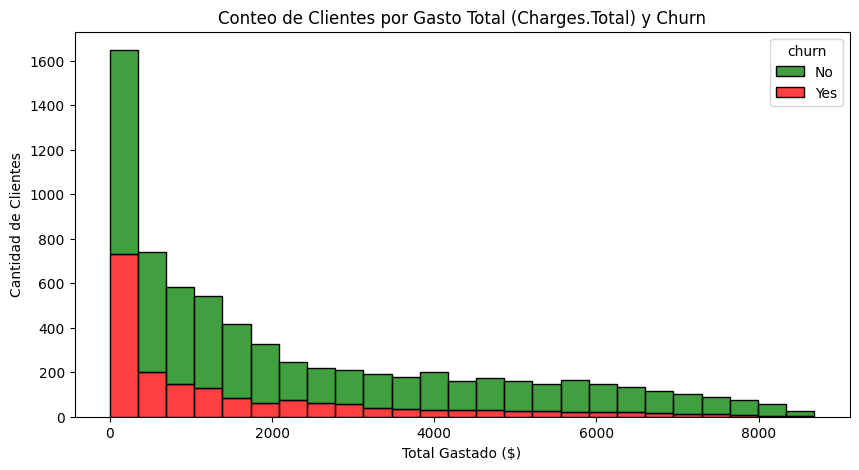

In [299]:
import seaborn as sns
import matplotlib.pyplot as plt

colores_personalizados = {"Yes": "red", "No": "green"}

plt.figure(figsize=(10, 5))

sns.histplot(
    data=Telecom_X_normalizado,
    x='charges.total',
    hue='churn',
    multiple="stack",
    palette=colores_personalizados,
    hue_order=["No", "Yes"],
)

plt.title('Conteo de Clientes por Gasto Total (Charges.Total) y Churn')
plt.xlabel('Total Gastado ($)')
plt.ylabel('Cantidad de Clientes')
plt.show()

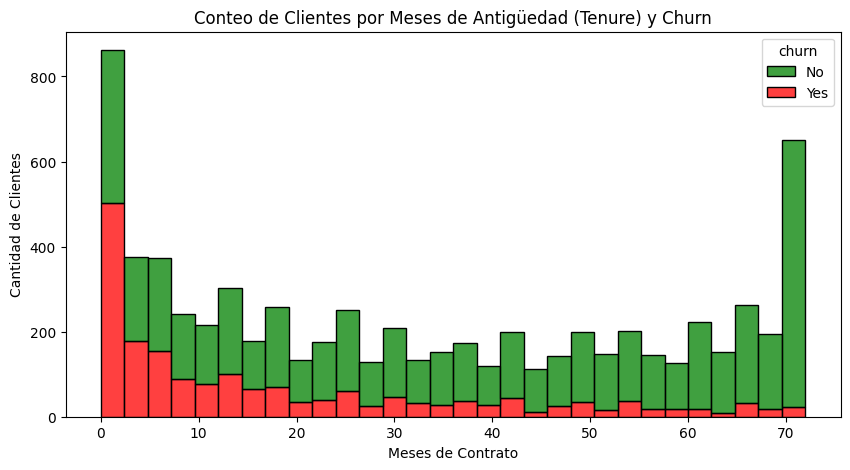

In [300]:

colores_personalizados = {"Yes": "red", "No": "green"}

plt.figure(figsize=(10, 5))


sns.histplot(
    data=Telecom_X_normalizado,
    x='tenure',
    hue='churn',
    multiple="stack",
    palette=colores_personalizados,
    hue_order=["No", "Yes"], # Verde abajo, Rojo arriba
    bins=30
)

plt.title('Conteo de Clientes por Meses de Antigüedad (Tenure) y Churn')
plt.xlabel('Meses de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.show()

#📄Informe final


##**1. 🔹 Introducción**

El objetivo principal de este proyecto es analizar el comportamiento de los clientes de Telecom X para entender las causas de la evasión (Churn). El problema central radica en identificar qué perfiles de usuario tienen mayor probabilidad de abandonar el servicio, permitiendo a la empresa tomar decisiones proactivas para retenerlos.


##**2. 🔹 Metodología Técnica y Herramientas**

Para este análisis se utilizó el ecosistema de ciencia de datos de Python, destacando las siguientes librerías:

Pandas: Utilizada para la manipulación de datos, creación de tablas cruzadas (crosstab) y segmentación por rangos (qcut y cut).

Matplotlib: Librería base para la generación de la estructura de los gráficos y personalización de figuras.

Seaborn: Herramienta principal de visualización estadística. Se utilizaron métodos como sns.histplot para ver distribuciones y sns.boxplot para identificar valores atípicos.

Procesamiento: Se trabajó sobre un DataFrame normalizado (Telecom_X_normalizado) para asegurar la consistencia en los ejes de los gráficos.










##**3. 🔹 Análisis Exploratorio de Datos (EDA)**
El análisis se dividió en dos dimensiones críticas: temporalidad y finanzas.

A. Dimensión Temporal: Tenure (Antigüedad)
Método: Se utilizó un histograma apilado (multiple="stack") con una paleta de colores semántica (Verde para "No", Rojo para "Yes").

Hallazgo: Existe un volumen masivo de cancelaciones en el primer año (0-12 meses).

B. Dimensión Financiera: Charges.Total (Gasto Total)
Método: Visualización de la distribución del gasto acumulado mediante sns.histplot.

Hallazgo: La mayor densidad de evasión se concentra en clientes con gastos totales bajos, lo que confirma que la fuga es temprana y el cliente no llega a generar rentabilidad a largo plazo.

C. Servicios Adicionales (Suscripciones)
Análisis: Se revisaron servicios como OnlineSecurity, TechSupport y StreamingTV.

Hallazgo: Los clientes con servicios de valor agregado (soporte técnico y seguridad) tienden a tener tasas de evasión más bajas en comparación con aquellos que solo tienen el servicio básico de internet.


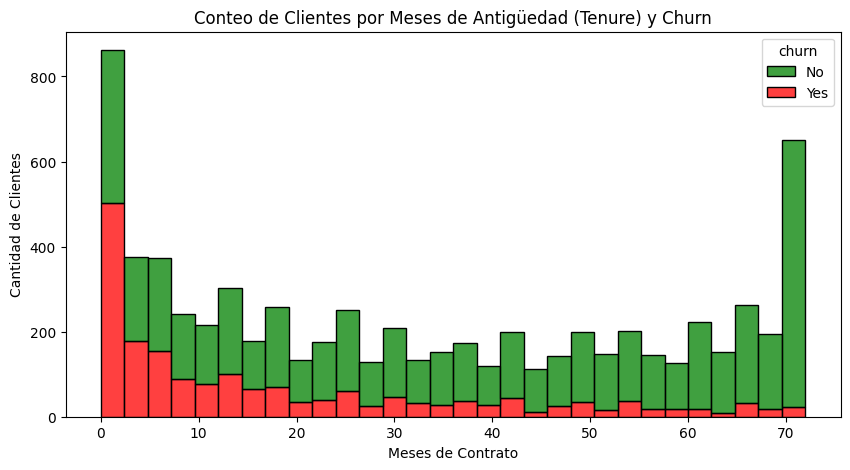

In [301]:
colores_personalizados = {"Yes": "red", "No": "green"}

plt.figure(figsize=(10, 5))


sns.histplot(
    data=Telecom_X_normalizado,
    x='tenure',
    hue='churn',
    multiple="stack",
    palette=colores_personalizados,
    hue_order=["No", "Yes"], # Verde abajo, Rojo arriba
    bins=30
)

plt.title('Conteo de Clientes por Meses de Antigüedad (Tenure) y Churn')
plt.xlabel('Meses de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.show()

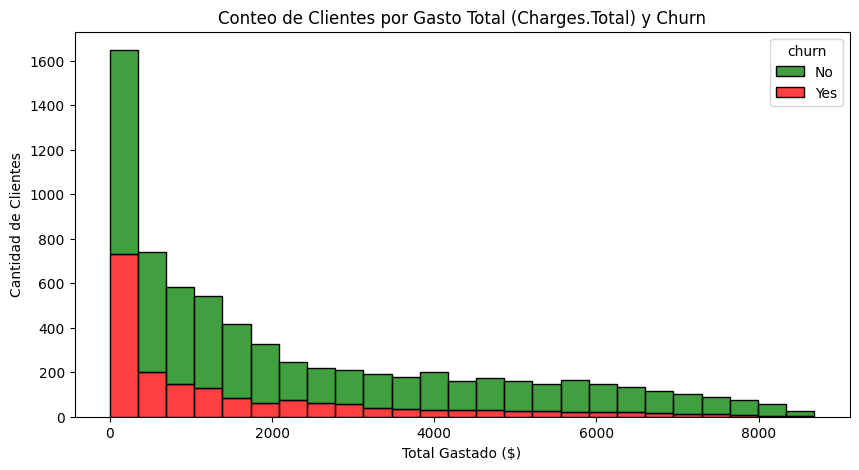

In [302]:
import seaborn as sns
import matplotlib.pyplot as plt

colores_personalizados = {"Yes": "red", "No": "green"}

plt.figure(figsize=(10, 5))

sns.histplot(
    data=Telecom_X_normalizado,
    x='charges.total',
    hue='churn',
    multiple="stack",
    palette=colores_personalizados,
    hue_order=["No", "Yes"],
)

plt.title('Conteo de Clientes por Gasto Total (Charges.Total) y Churn')
plt.xlabel('Total Gastado ($)')
plt.ylabel('Cantidad de Clientes')
plt.show()

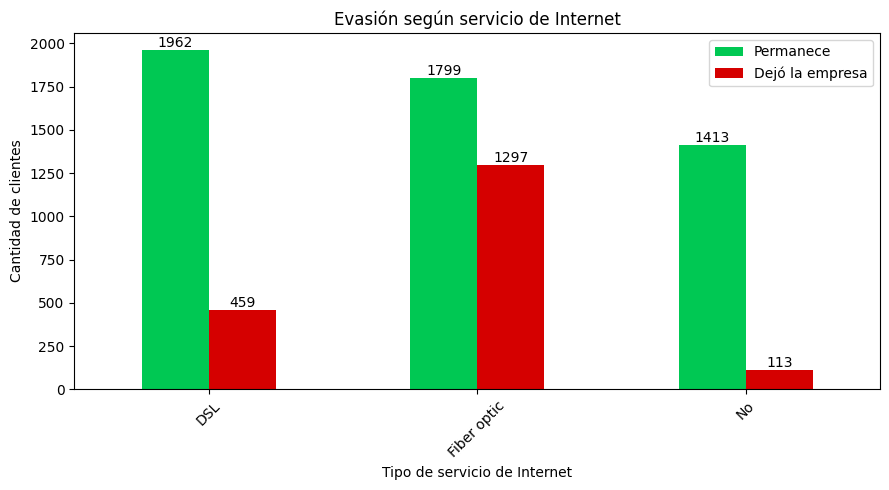

In [303]:

ax = columna_internet.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    figsize=(9,5)

)

plt.title("Evasión según servicio de Internet")
plt.ylabel("Cantidad de clientes")
plt.xlabel("Tipo de servicio de Internet")
plt.legend(["Permanece", "Dejó la empresa"])
plt.xticks(rotation=45)


for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

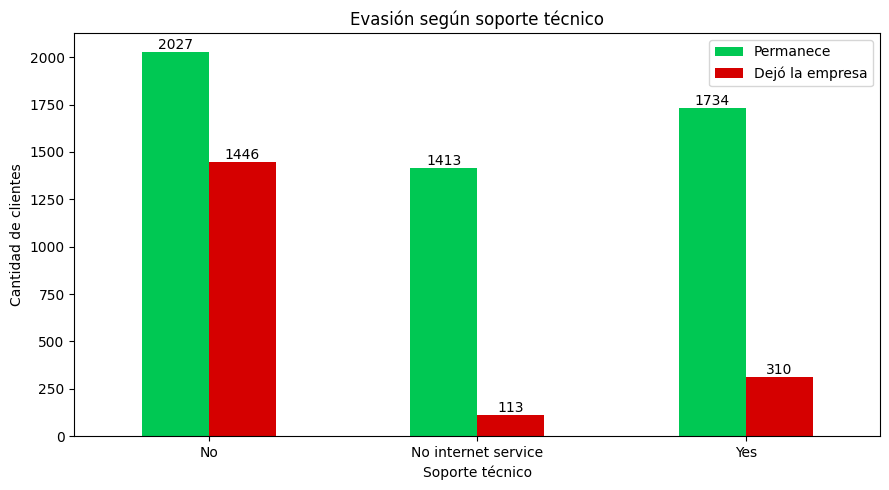

In [304]:
ax = columna_tech.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    figsize=(9,5)
)

plt.title("Evasión según soporte técnico")
plt.ylabel("Cantidad de clientes")
plt.xlabel("Soporte técnico")
plt.legend(["Permanece", "Dejó la empresa"])
plt.xticks(rotation=0)


for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

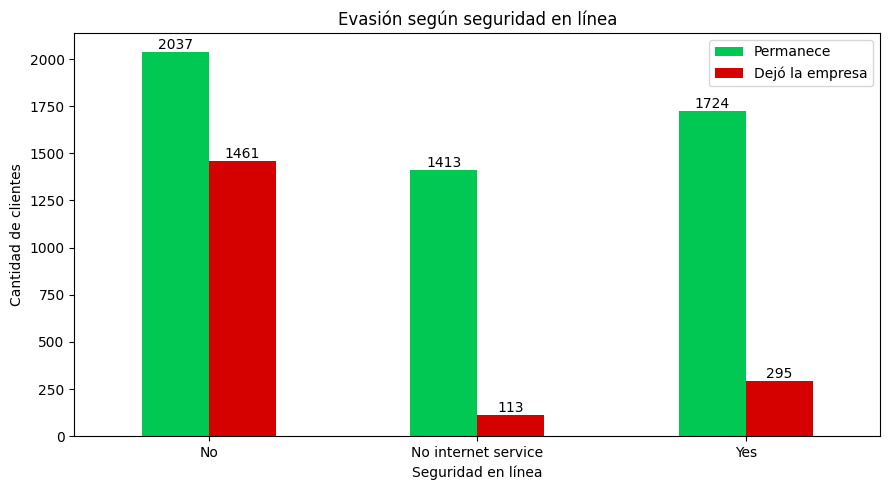

In [305]:
ax = columna_security.plot(
    kind="bar",
    color=["#00C853", "#D50000"],
    figsize=(9,5)
)

plt.title("Evasión según seguridad en línea")
plt.ylabel("Cantidad de clientes")
plt.xlabel("Seguridad en línea")
plt.legend(["Permanece", "Dejó la empresa"])
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

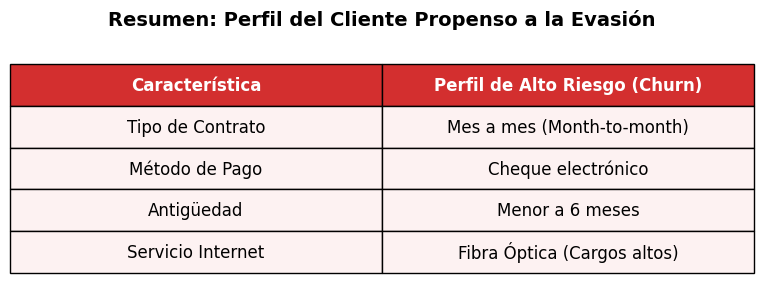

In [307]:
import matplotlib.pyplot as plt

# Datos de la tabla de riesgo
data = [
    ["Tipo de Contrato", "Mes a mes (Month-to-month)"],
    ["Método de Pago", "Cheque electrónico"],
    ["Antigüedad", "Menor a 6 meses"],
    ["Servicio Internet", "Fibra Óptica (Cargos altos)"]
]

column_labels = ["Característica", "Perfil de Alto Riesgo (Churn)"]

# Crear la figura
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

# Crear la tabla
tabla = ax.table(cellText=data, colLabels=column_labels, cellLoc='center', loc='center')

# Estilo de la tabla
tabla.auto_set_font_size(False)
tabla.set_fontsize(12)
tabla.scale(1.2, 2.5) # Ajustar tamaño de celdas

# Color de los encabezados
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#d32f2f') # Rojo oscuro para el encabezado
    else:
        cell.set_facecolor('#fdf2f2') # Rojo muy claro para las filas

plt.title("Resumen: Perfil del Cliente Propenso a la Evasión", fontsize=14, pad=20, weight='bold')
plt.show()



##**4. 🔹 Conclusiones e Insights**

Factor Crítico: El tipo de contrato es el predictor más fuerte; los contratos mensuales tienen una correlación directa con el Churn alto.

Fuga Temprana: La empresa pierde a la mayoría de sus clientes antes de que estos cumplan los dos años de antigüedad.

Valor Percibido: Los cargos mensuales altos sin servicios de soporte adicionales generan una percepción de "servicio costoso", disparando la evasión.



##**5🔹 Recomendaciones Estratégicas**

Fidelización Temprana: Crear campañas de marketing específicas para clientes en su mes 6 y mes 11, ofreciendo beneficios por renovar el contrato.

Estrategia de Bundling: Empaquetar servicios de OnlineSecurity y TechSupport de forma gratuita o con descuento para clientes nuevos, ya que estos servicios actúan como "anclas" de retención.

Conversión de Contrato: Ofrecer una transición guiada de contratos "Mes a Mes" hacia "Anual" mediante una reducción pequeña en el cargo mensual a cambio de la permanencia.

